# [1교시]

1. 함수와 프로시저 실습 데이터 생성 스크립트

- Procedure(프로시저): 특정 작업을 수행하기 위해 일련의 명령어들을 하나로 묶어놓은 절차나 루틴

- 프로시저 VS 함수
특정 작업 / 특정계산
리턴 값을 가질수도, 안가질수도 / 리턴값을 반드시 가져야함
리턴값을 여러개 / 리턴값은 하나
DB에 기술 / Client에 기술
단독으로 문장 구성 / 단독으로 문장 구성 불가

- select count(*) from 테이블명;을 할 때 테이블이 적용이 안되면 from 뒤에 상위 폴더명.테이블명;을 하면 된다.
- count as cnt를 통해 count를 cnt로 부를 수 있게 만든다.

- union all : count 명령어로 계산을 할 때 각 명령어 뒤에 union all을 붙이면 묶어서 dbframe을 만들어준다.

- table내에서 특정 수를 구할 때 : where을 사용

- update shop_db.customers c
- set c.email = " "
- --> " "중복때문에 오류로 지워지지 않음




In [ ]:
-- 전체고객수 count()
-- 총 매출액 sum()
-- 평균 주문 금액 avg()
-- 최고가 상품 max()
-- 최저가 상품 min()

-- GROUP BY : 특정 기준으로 그룹을 나누어 그룹별로 집계를 수행
-- 고객등급별 통계
-- Bronze 고객 : 평균포인트
-- Silver 고객
-- Gold 고객

-- 데이터 건수
-- select count(*) as cnt from shop_db.customers;

In [ ]:
select '고객' as '구분', count(*) as cnt from shop_db.customers C
union all
select '상품', count(*) as cnt from shop_db.products p
union all
select '주문', count(*) as cnt from shop_db.orders O
union all
select '주문상세', count(*) as cnt from shop_db.order_details od;

-- 전체고객 파악
select count(*) as '고객수' from shop_db.customers C;

-- 고객등급중에 Gold 고객의 수를 구해라
select count(*) as 'Gold 고객 수' from shop_db.customers C
where c.grade = 'Gold' ;

-- update
update shop_db.customers c
set c.email = null
where c.customer_id = 1
;

-- null 제외 카운트
-- 이메일을 등록한 고객 수
-- select count(c.email) from shop_db.customers C ;

-- 이메일 등록/미등록 고객 깔끔하게 정리
select
count(*) as '전체고객수',
count(c.email) as '이메일 등록 고객',
count(*) - count(c.email) as '이메일 미등록 고객'
from shop_db.customers C ;

-- sum 합계 계산
-- 전체 매출액
select sum(O.total_amount) as '총매출액' from shop_db.orders O;
-- 완료된 주문만 합계
select sum(O.total_amount) as '확정매출액' from shop_db.odrders O
where O.status = 'Completed';

select '총매출액' as '구분', sum(o.total_amount) as '금액' from shop_db.orders o
union all
select '확정매출액', sum(o.total_amount) from shop_db.orders o
where o.status = 'Completed';

# [2교시]

In [ ]:
-- 상품재고 현황 재고 == stock
select
	sum(p.stock) as '총 재고 수량',
	sum(p.price * p.stock) as '총 재고 금액'
from shop_db.products p;

In [ ]:
-- AVG
-- 평균 주문 금액 orders
select
	avg(O.total_amount) as '평균 주문 금액',
	sum(O.total_amount) as '총 주문 금액',
count(O.total_amount) as '총 주문 개수'
from shop_db.orders o ; -- * 대신 해당 컬럼을 지정해서 하면 null을 제외하고 값을 구한다


In [ ]:
-- 평균 상품 가격 
select avg(p.price) from shop_db.products p;
-- 평균 고객 포인트
select round(avg(c.point),2) from shop_db.customers c;

-- min, max

-- group by - 그룹별 집계alter
-- select
-- 그룹컬럼, 집계함수(컬럼)
-- from 테이블
-- group by 그룹컬럼 (그룹컬럼이 아닌 애들은 개별컬럼으로 올 수 없다)

-- 동작원리
-- 1. 그룹컬럼의 값이 같은 행들을 모음
-- 2. 각 그룹별로 집계 함수 계산
-- 3. 그룹별 결과물 반환

select
	c.grade as '등급',
	avg(c.point) as '평균포인트',
	sum(c.point) as '총포인트',
	count(*) as '등급별 고객수'
	from shop_db.customers c
	group by c.grade
;   

In [ ]:
-- 카테고리별 상품수 평균가격 총재고
select
	p.category as '카테고리',
	count(*) as '상품수',
    round(avg(p.price),2) as '평균가격',
	sum(p.stock) as '총재고'
from shop_db.products p
group by p.category
order by round(avg(p.price),2) desc
;

# [3교시]

In [ ]:
-- 주문 상태별 통계
select
o.status as '주문상태',
count(*) as '주문건수',
sum(o.total_amount) as '총금액'
from shop_db.orders o 
group by o.status
;

-- 다중 컬럼 그룹화
-- 등급별 + 가입연도별 통계
-- group by에 있는건 바로 쓸 수 있지만, 없는건 group by로 묶어줘야 한다.
select
c.grade as '등급',
year(c.join_date) as '가입연도',
count(*) as '고객수'
from shop_db.customers c
group by c.grade, year(c.join_date)
order by 가입연도 desc, 등급
;

-- 카테고리별 + 가격대별 상품 수
select
p.category as '카테고리',
case
	when price < 30000 then '저가'
    when price < 100000 then '중가'
	else '고가'
end as '가격대',
count(*) as '상품수',
round(avg(p.price)) as '평균가격'
from shop_db.products p
group by p.category, 가격대
order by 평균가격 desc
;

In [ ]:
-- having 그룹 필터링
-- having은 where와 다른 개념
-- 구분	where			having
-- 대상	개별행			그룹된 결과
-- 시점	group by 전		group by 후
-- 함수 	집계함수 불가		집계함수 가능alter

select
grade, count(*)
from shop_db.customers c 
where c.point > 1000
group by grade
having count(*) > 5
;

-- 평균포인트가 3000점 이상인 등급, 고객수, 평균포인트
select
c.grade as '등급',
count(*) as '고객수',
round(avg(c.point),0) as '평균포인트'
from shop_db.customers c
group by c.grade
having 평균포인트 >= 3000
order by 평균포인트 desc
;

# [4교시]

In [ ]:
-- where + having
-- where 완료된 주문만 선택(개별 행 필터)
-- having : 2회이상 주문한 고객(그룹 선택)

In [ ]:
select
o.customer_id as '고객번호',
count(*) as '주문횟수'
from shop_db.orders o
where o.status = 'Completed' -- 명령어와 테이블명의 구분을 잘 해야한다(대, 소문자)
group by o.customer_id
having 주문횟수 >= 2
;

In [ ]:
-- product에서 category별로 총 매출을 정렬(order by ' ' desc)한 다음에 top3(=limit 3)
select * from shop_db.products p
order by p.price desc
limit 3;

In [ ]:
-- 월별 매출
-- 2024년 2월 일자별 매출 분석
-- 주문일자
-- 주문건수
-- 일일매출
-- 평균주문금액
-- 최대주문금액
select 
date(o.order_date) '주문일자',
count(*) as '주문건수',
sum(o.total_amount) as '일일매출',
round(avg(o.total_amount), 0) as '일일_평균_주문_금액',
max(o.total_amount) as '일일_최대_주문_금액'
from shop_db.orders o
where o.order_date >= '2024-02-01' and o.order_date <'2024-03-01'
group by date(o.order_date)
order by date(o.order_date) desc
;

In [ ]:
-- 주문 상태별 현황 (비율 포함) ==> 서브쿼리
select
	status as '주문_상태',
	count(*) as '건수',
    round(count(*) * 100.0 / (select count(*) from shop_db.orders), 1) as '비율(%)',
    sum(total_amount) as '금액',
    round(avg(total_amount), 0) as '평균_금액'
from shop_db.orders
group by status
order by 건수 desc;

1-4교시 핵심내용
- 집계 함수: COUNT, SUM, AVG, MAX, MIN으로 데이터 요약
- GROUP BY: 특정 컬럼 기준으로 그룹화하여 집계
- HAVING: 그룹화된 결과를 필터링
- WHERE vs HAVING:
- WHERE: 개별 행 필터 (집계 전)
- HAVING: 그룹 필터 (집계 후)

In [ ]:
-- 국가별 총인구수 top5

select
  c.name as 국가,
  c.population as 총_인구수
from world.country as c
order by c.population desc
limit 5
;

# [5교시]
JOIN

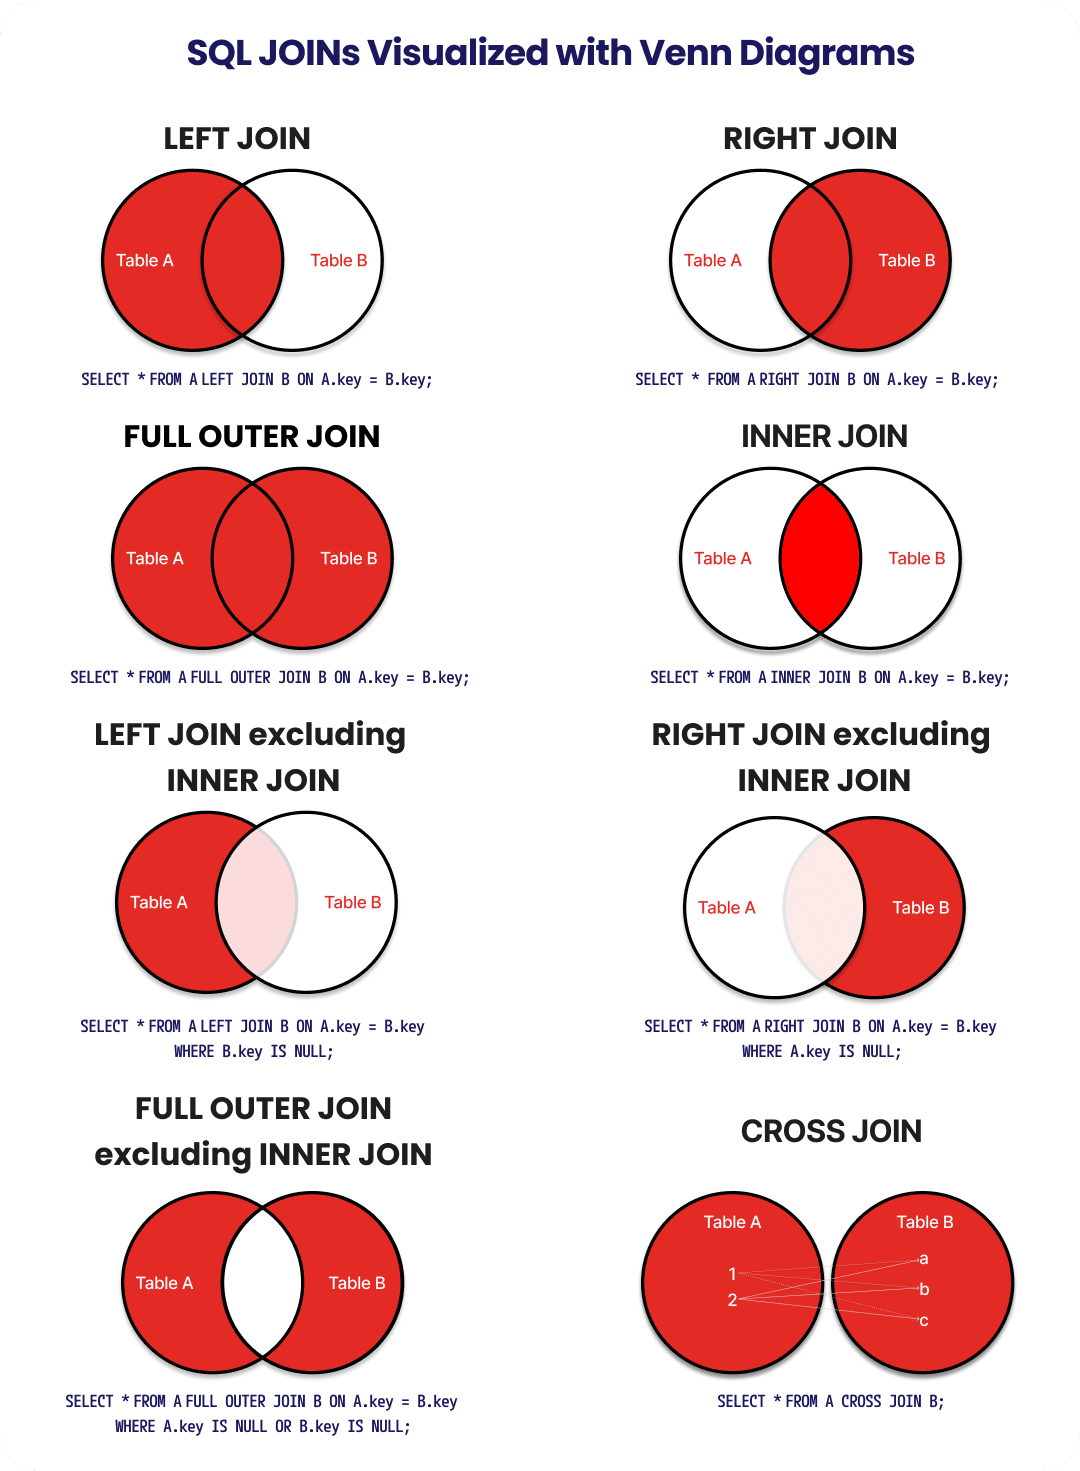

# INNER JOIN
- select * from a right join b on a .key = b.key
- where A.key IS NULL;

sql workbench의 eer
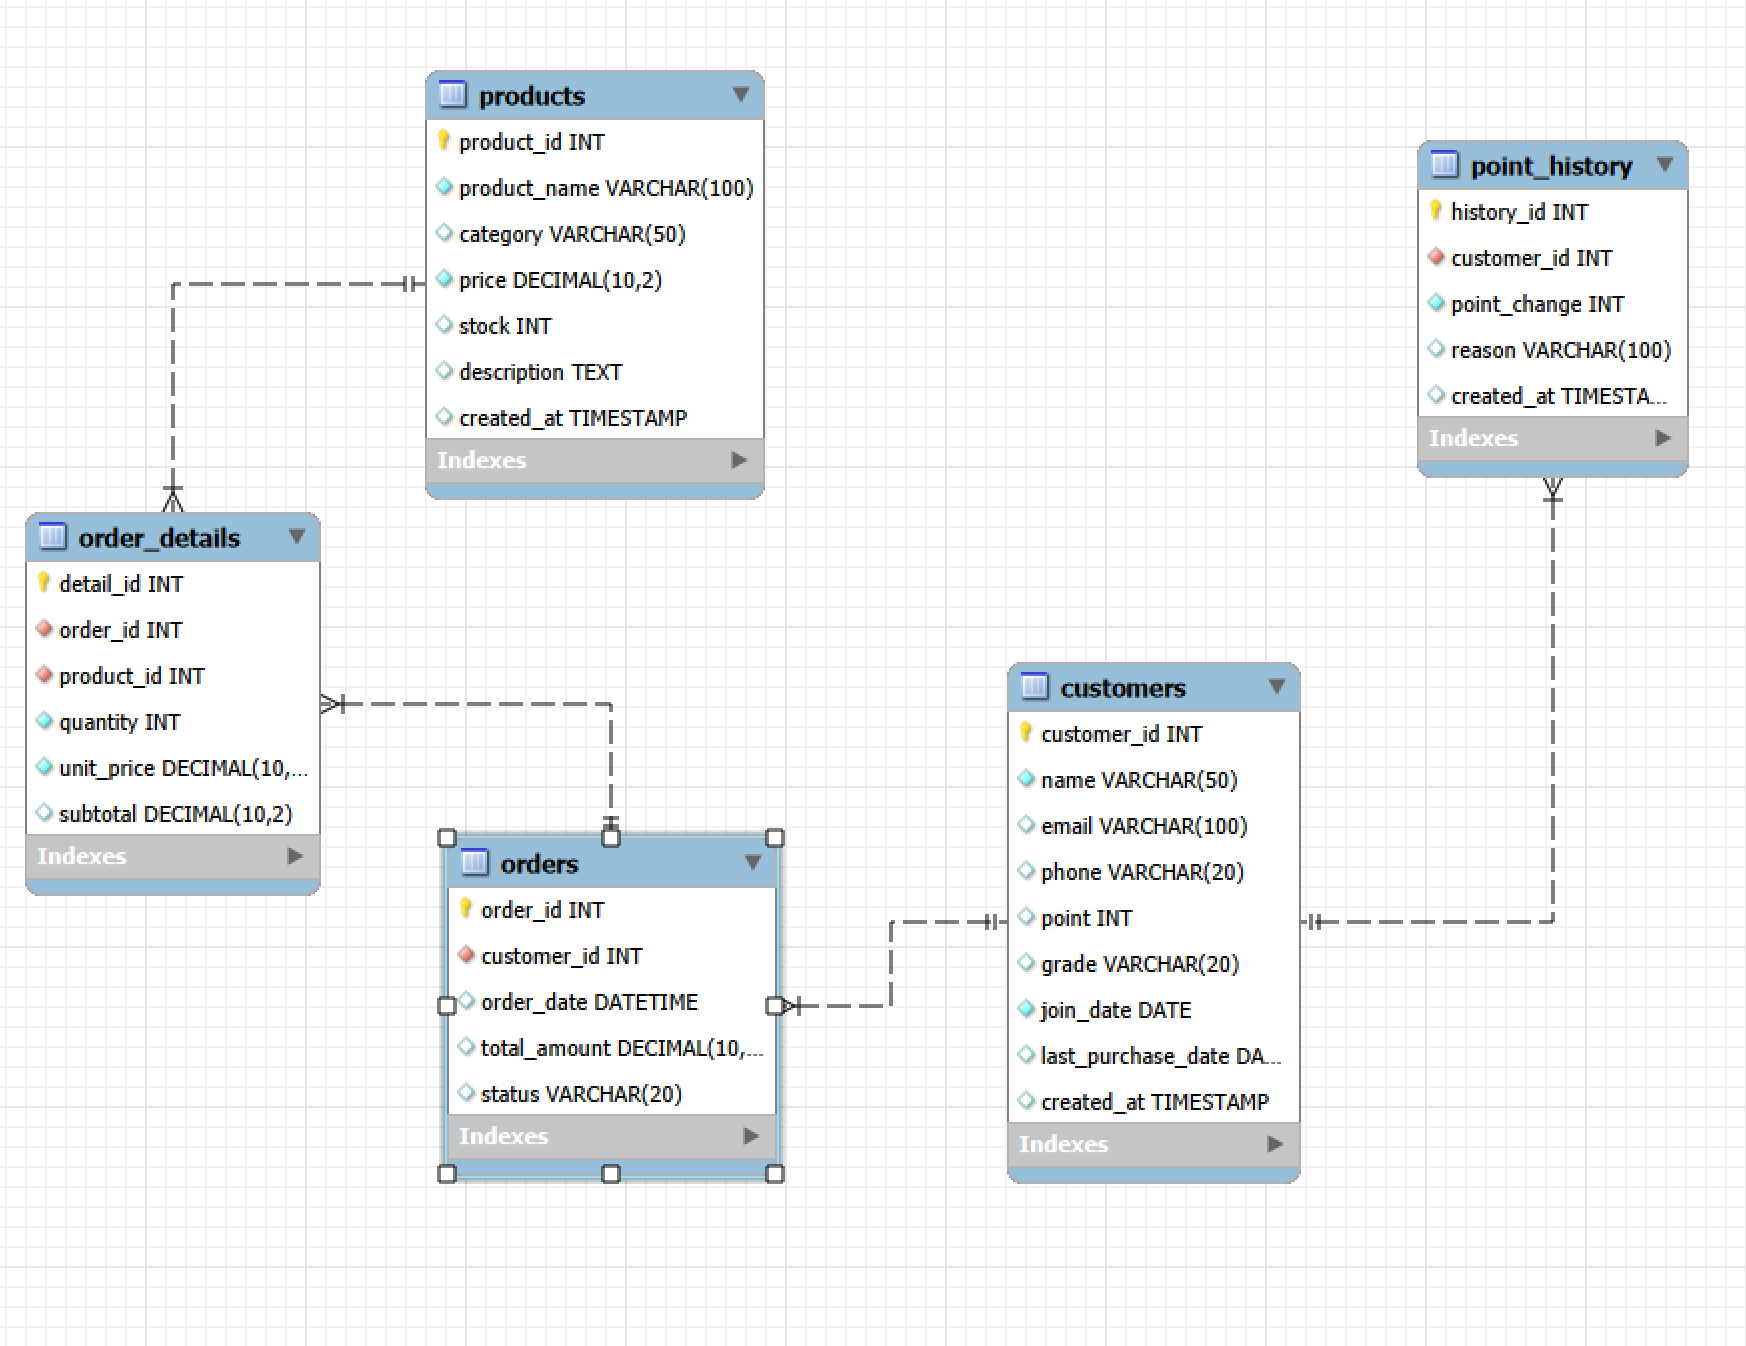

In [ ]:
-- 고객 + 주문 정보
select
c.name as 고객명,
o.total_amount as 주문금액
from shop_db.customers c
inner join shop_db.orders o
on c.customer_id = o.customer_id
order by o.total_amount desc
limit 2
;

-- 주문 + 주문상세
-- 주문일시, 수량, 금액
select
o.order_date as '주문일시',
od.quantity as '수량',
od.subtotal as '금액'
from shop_db.orders o
join shop_db.order_details od -- join의 기본은 inner join이지만 생략도 가능
on o.order_id = od.order_id
;

-- 특정 주문의 상품 상세 정보 order_id = 1
-- order order_detail
select
o.order_date as '주문일시',
od.quantity as '수량',
od.subtotal as '금액'
from shop_db.orders o
join shop_db.order_details od 
on o.order_id = od.order_id
where o.order_id = 1
;

-- gold 등급의 고객 주문정보만 추출
select
*
from shop_db.customers c 
inner join shop_db.orders o
on c.customer_id = o.customer_id
where c.grade = 'Gold'
;

# CROSS JOIN
SELECT * FROM A CROSS JOIN B;

# LEFT JOIN
SELECT *FROM A LEFT JOIN B ON A.key = B.key;

# RIGHT JOIN
SELECT * FROM A RIGHT JOIN B ON A.key = B.key;

left join / right join
- 왼쪽 테이블의 모든 행을 포함하고 오른쪽 테이블은 매칭되는 것만
- 주문한 고객 + 주문하지 않은 고객 모두 조회
- 주문이 없으면 orders의 컬럼은 null

In [ ]:
select
*
from shop_db.customers c
left join shop_db.orders o
on c.customer_id = o.customer_id
;

delete from shop_db.orders o where o.customer_id = 5;

select * from shop_db.orders o;

select count(*) from shop_db.customers c;

# [6교시]

In [ ]:
DROP DATABASE IF EXISTS jointest;
CREATE DATABASE jointest;
USE jointest;

CREATE TABLE jointest.A (
  A_id INT AUTO_INCREMENT PRIMARY KEY,
  price INT NOT NULL
);

CREATE TABLE jointest.B (
  B_id INT AUTO_INCREMENT PRIMARY KEY,
  A_id INT,
  amount INT NOT NULL,
  FOREIGN KEY (A_id) REFERENCES A(A_id) ON DELETE CASCADE
);

INSERT INTO A (price) VALUES
(1),(2),(3),(4),(5),(6);

INSERT INTO B (A_id, amount) VALUES
(1, 10), (2, 20), (3, 30);

select *
from jointest.A as a
left join jointest.B as b
on a.A_id = b.A_id

union

select *
from jointest.A a
right join jointest.B b
on a.A_id = b.A_id
;

마지막 SELECT문에서 inner 부분을 left, right로 바꾸면 집합이 바뀌며 바뀐 값을 확인 가능하다

In [ ]:
DROP DATABASE IF EXISTS jointest;
CREATE DATABASE jointest;
USE jointest;

CREATE TABLE jointest.A (
  A_id INT AUTO_INCREMENT PRIMARY KEY,
  price INT NOT NULL
);

CREATE TABLE jointest.B (
  B_id INT AUTO_INCREMENT PRIMARY KEY,
  A_id INT,
  amount INT NOT NULL,
  FOREIGN KEY (A_id) REFERENCES A(A_id) ON DELETE CASCADE
);

INSERT INTO A (price) VALUES
(1),(2),(3),(4),(5),(6);

INSERT INTO B (A_id, amount) VALUES
(1, 10), (2, 20), (3, 30);

select *
from jointest.A as a
left join jointest.B as b
on a.A_id = b.A_id
where b.B_id is null
;

select *
from jointest.A a
cross join jointest.B b
;

select *
from jointest.A a, jointest.B b
;

select * from jointest.B;

-- inner join / left join / cross join => join없이 나열하면 같은 의미

-- pk, fk 관계를 고려하면... pk에 해당하는 테이블이 왼쪽, 오른쪽은 fk

In [ ]:
# 예제
select
	c.name as '고객명',
	c.grade as '등급',
	o.order_id as '주문번호',
	o.order_date as '주문일시',
	o.total_amount as '총금액',
	od.detail_id as '상세번호',
	od.quantity as '수량',
	od.subtotal as '소계'
from shop_db.customers c
	inner join shop_db.orders o on c.customer_id = o.customer_id
    inner join shop_db.order_details od on o.order_id = od.product_id
where o.order_id = 1;

# [7교시]

In [ ]:
# conda환경에 mysql 설치하는 명령어
%conda install mysql-connector-python

In [ ]:
# mysql 실행 명령어
import mysql.connector as mc
# mysql에서 Error만 가져오기
from mysql.connector import Error

In [ ]:
def insert_data(conn):
    # 데이터 삽입
    sql = 'INSERT INTO customers ' \
    '(name, email, phone, point, grade, join_date, last_purchase_date) ' \
    'VALUES(%s,%s,%s,%s,%s,%s,%s)'

    values = ('홍길동', 'hong.cs@email.com', '010-1111-0001', 5000, 'Gold', '2023-01-15', '2024-02-20')

    cursor = conn.cursor()
    cursor.execute(sql, values)
    conn.commit()

In [ ]:
conn = None
try:    
    conn =  mc.connect(
        host = 'localhost',  # DB 주소(127.0.0.1)
        user = 'root',
        password = 'Zjflwl12!!',
        database = 'shop_db'
    )
    if conn.is_connected:
        print('접속성공')     
    insert_data(conn)
except Error as e:
    print(f'데이터베이스 오류 : {e}')   
finally:
    if conn:
        conn.close()        
        print('연결 해제')

# [8교시]

In [ ]:
%conda install mysql-connector-python python-dotenv pandas

In [ ]:
import mysql.connector as mc
from mysql.connector import Error
from datetime import datetime, timedelta
import os
from dotenv import load_dotenv
import pandas as pd

In [ ]:
load_dotenv()

In [ ]:
os.getenv('DB_PASSWORD')

In [ ]:
DB_CONFIG = {
    'host' : os.getenv('DB_HOST'),
    'user' : os.getenv('DB_USER'),
    'password' : os.getenv('DB_PASSWORD'),
    'database' : os.getenv('DB_NAME'),
    'port' : os.getenv('DB_PORT')
}

In [ ]:
DB_CONFIG

In [ ]:
class ShopDB:
    '''
    쇼핑몰 데이터베이스 관리 클래스
    '''
    def __init__(self, host, user, password, database, port=3306):
        self.host = host
        self.user = user
        self.password = password
        self.database = database
        self.port = port
    def connect(self):
        try:
            self.conn = mc.connect(host=self.host, user=self.user,
                        password=self.password, database=self.database,
                        port=self.port)
            self.cursor = self.conn.cursor()
            self.cursor.execute(f'use {self.database}')
            return True
        except Error as e:
            print(f'데이터베이스 에러 : {e}')
            return False
    def close(self):
        '''연결종료'''
        if self.cursor:
            self.cursor.close()
        if self.conn and self.conn.is_connected():
            self.conn.close()
        print('연결 종료')

In [ ]:
sh = ShopDB(**DB_CONFIG)
sh.connect()

In [ ]:
sh.close()